In [1]:
import numpy as np 
import healpy as hp 
# Specify the follwing:
# ================================================
# The shape of the maps is (N_bins,N_pix)
# The shape of cls is (N_bins,N_bins,gen_lmax + 1)
# The shape of pixwin is (gen_lmax + 1)
# ================================================
path2map      = '/home/ivanespinoza/GPTG/Extended_Lognormal/data/Kappa_Gower_St_ID_44_DESy3_tomography_Nside_256.npy'
path2lpmap    = '/home/ivanespinoza/GPTG/Extended_Lognormal/data/Kappa_Gower_St_ID_44_DESy3_tomography_Nside_256_lowpassed_pix.npy'
path2pixwin   = '/home/ivanespinoza/GPTG/Extended_Lognormal/data/pixwin_256.npy'
path2cls      = '/home/ivanespinoza/GPTG/Extended_Lognormal/data/UNBIASED_3point75nsideminus1_Cls_NG_Gower_St_ID_44.npy'
bias_path     = '/spiff/ivanespinoza/KaRMMa_data/photo_z_derivatives/bias.npy'
nz_path       = '/spiff/ivanespinoza/KaRMMa_data/source_distributions/desy3/'
N             = 3
# ================================================
bias          = np.load(bias_path)
kappa_map     = np.load(path2map)
kappa_map_lp  = np.load(path2lpmap)

cl_NG         = np.load(path2cls)

N_bins        = kappa_map.shape[0]
N_pix         = kappa_map.shape[1]
Nside         = hp.npix2nside(N_pix)   
nz            = [np.load(nz_path+'/source_bin%d.npy'%(i+1)) for i in range(N_bins)]
gen_lmax      = 3*Nside-1   
lmax          = 2*Nside

# ==== For comparison

cl_G_correct   = np.load('/home/ivanespinoza/GPTG/Extended_Lognormal/data/cl_G.npy')
params_correct = np.load('/home/ivanespinoza/GPTG/Extended_Lognormal/data/params.npy') 

In [2]:
from cosmock.fitter import fit_gn_with_constraint,histogramer2d

fitted_params_w_cls = np.zeros((N_bins,N)) # Fits (N-1)-degrees of freedom
for i in range(N_bins):
    x,y                  = histogramer2d(kappa_map[i],1000,(-10,4.5))
    fitted_params_w_cls[i] = fit_gn_with_constraint(x,y,N,cl_NG[i,i,:3*Nside])

print(np.array_equal(fitted_params_w_cls,params_correct))

True


In [3]:
from cosmock.Cls import C_NG_to_C_G

cl_G = C_NG_to_C_G(cl_NG, fitted_params_w_cls, N_bins, N)
cl_G = cl_G[:,:,:3*Nside]
print(np.array_equal(cl_G,cl_G_correct))

True


In [5]:
ell_pixwin, _     = hp.Alm.getlm(lmax)
pixwin            = np.load(path2pixwin)
pixwin_ell_filter = pixwin[ell_pixwin]

In [6]:
from cosmock.mocker import get_y_maps,get_kappa,get_kappa_pixwin

y_maps, _      = get_y_maps(cl_G, Nside, N_bins, gen_lmax)
kappa_mock     = get_kappa(y_maps, N_bins, N, fitted_params_w_cls)  
kappa_mock_pix = get_kappa_pixwin(y_maps,N_bins,N,fitted_params_w_cls,Nside,pixwin_ell_filter)

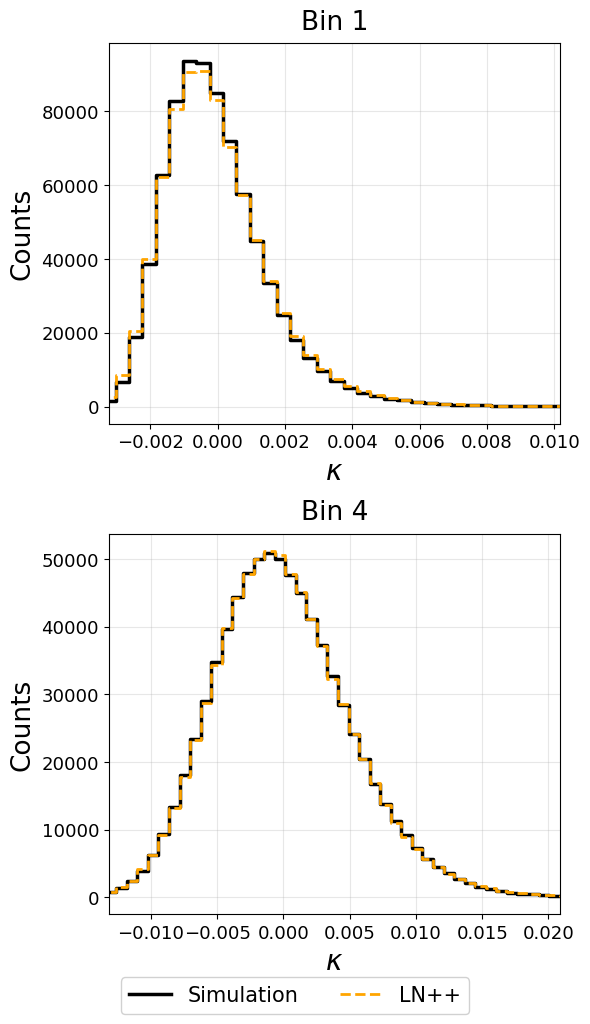

In [8]:
import matplotlib.pyplot as plt 
# Same plot as above but as a column (bin 1 top, bin 4 bottom)
bin_indices = [0, 3]
bin_labels  = ['Bin 1', 'Bin 4']

fig, axes = plt.subplots(2, 1, figsize=(6, 10))

for row, (idx, label) in enumerate(zip(bin_indices, bin_labels)):
    ax = axes[row]

    counts_sim, bins = np.histogram(kappa_map_lp[idx], bins=100)
    counts_n3,  _    = np.histogram(kappa_mock_pix[idx], bins=bins)

    ax.step(bins[:-1], counts_sim, where='post', color='black', lw=2.5, label='Simulation')
    ax.step(bins[:-1], counts_n3,  where='post', color='orange', lw=2,   ls='dashed', label='LN++')
    ax.set_ylabel('Counts', fontsize=19)
    ax.set_xlabel(r'$\kappa$', fontsize=20)
    ax.grid(alpha=0.3)
    ax.tick_params(labelsize=13)
    ax.set_title(label, fontsize=19, pad=10)

    xlo = np.percentile(kappa_map_lp[idx], 0.1)
    xhi = np.percentile(kappa_map_lp[idx], 99.9)
    ax.set_xlim(xlo, xhi)

# Single legend centered below both panels
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.03),
           ncol=3, fontsize=15, framealpha=0.9)
plt.tight_layout()
plt.subplots_adjust(bottom=0.08)
plt.show()
plt.close()